In [1]:
import pandas as pd

In [2]:
#Loading the data files

# orders_cl.csv
url = "https://drive.google.com/file/d/1ZnraC-SOP9Chzxb2Hbq9hNF-2APrBlxP/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_cl = pd.read_csv(path)

# orderlines_cl.csv
url = "https://drive.google.com/file/d/1TrITdans15tKc4ynVEXHvGDJh5FsSy92/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_cl = pd.read_csv(path)

# products_cl.csv
url = "https://drive.google.com/file/d/1Y-PNPKsL9bMJW3wDqPBjXyACy7MYIdHj/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cl = pd.read_csv(path)

In [3]:
#Create copies

orders_qu= orders_cl.copy()
orderlines_qu= orderlines_cl.copy()
products_qu= products_cl.copy()

## 1.&nbsp; Define Pandas display format

In [4]:
pd.options.display.float_format = '{:,.2f}'.format
pd.set_option('display.max_rows', 1000)

## 2.&nbsp; Exclude unwanted orders

In [5]:
orders_qu.groupby('state').agg({'total_paid':'sum', 'order_id': 'count'})

,total_paid,order_id
state,,
Cancelled,"5,545,816.86",7233
Completed,"15,910,079.24",46605
Pending,"4,703,300.72",14374
Place Order,"17,087,858.32",40883
Shopping Basket,"85,912,559.93",117809


In [6]:
#Keeping only products with any of these 3 states Completed, Pending, or Place Oder

needed_index= orders_qu.loc[(orders_qu['state']== 'Completed') | (orders_qu['state']== 'Pending') | (orders_qu['state']== 'Place Order')].index
orders_qu= orders_qu.loc[needed_index]

In [8]:
orders_qu.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101862 entries, 1 to 226903
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      101862 non-null  int64  
 1   created_date  101862 non-null  object 
 2   total_paid    101862 non-null  float64
 3   state         101862 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 3.9+ MB


##&nbsp;**Keep only the orders that are present in both orders and orderlines**


Let's begin by looking if there's a big difference between the amount of orders present in orders and orderlines.

In [38]:
orders_qu['order_id'].nunique(),orderlines_qu.id_order.nunique()

(85885, 85885)

What a huge difference! We want to make sure that every order_id in orders also exists in orderlines and vice versa.

Hence we'll perform an inner merge on the two tables using the order_id & id_order. This will then keep only the order_id's that are present in both tables, which will then help us filter our _qu DataFrames once again.

In [11]:
# order_ids that are in both tables
needed_orders= orderlines_qu.merge(orders_qu, left_on='id_order', right_on= 'order_id', how = 'inner')['order_id']

In [12]:
#Filtering both dataframes
orders_qu = orders_qu.loc[orders_qu['order_id'].isin(needed_orders)]
orderlines_qu = orderlines_qu[orderlines_qu['id_order'].isin(needed_orders)]

## 3.&nbsp; Exclude orders with unknown products

In [14]:
orderlines_cl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293983 entries, 0 to 293982
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                293983 non-null  int64  
 1   id_order          293983 non-null  int64  
 2   product_id        293983 non-null  int64  
 3   product_quantity  293983 non-null  int64  
 4   sku               293983 non-null  object 
 5   unit_price        293983 non-null  float64
 6   date              293983 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 15.7+ MB


Let's start by investigating orderlines and products. We want to make sure that every product in orderlines has a matching entry in products. All orders with a missing product need to be removed from both orderlines and orders.

A left-join can help us here:

Joining orderlines left on products will keep all orderlines, and add the information of products on the matching skus. If an sku has been sold in orderlines, but the sku does not have an entry in products then the product_name will be empty.

In [15]:
# Get the index of rows containing unknown products
ol_p= orderlines_qu.merge(products_qu, on= 'sku', how= 'left')[["id_order","sku","name" ]]

#number of null values
ol_p.name.isna().sum()

2214

Looks like the vast majority of products are known.

We can't simply delete the rows containing unknown products. We need to remove the entirety of any order that contains an unknown product to keep a consistent and coherent dataset.

In [16]:
orders_to_delete= ol_p.loc[ol_p['name'].isna(), 'id_order'].unique()

Keep only orders in orders and orderlines, that are not in this list of corrupted orders.

In [17]:
# Drop these rows from the DataFrame
orders_qu= orders_qu.loc[~orders_qu['order_id'].isin(orders_to_delete)]

orderlines_qu= orderlines_qu.loc[~orderlines_qu['id_order'].isin
                                (orders_to_delete)]

## 4.&nbsp; Explore the revenue from different tables

Create the unit_price_total as orderlines.unit_price * orderlines.product_quantity



In [39]:
orderlines_qu['unit_price_total']= orderlines_qu['unit_price']*orderlines_qu['product_quantity']

In [19]:
#Group by id_order, summarising by the sum of unit_price_total

orderlines_qu.groupby('id_order')['unit_price_total'].sum()

,unit_price_total
id_order,
241423,129.16
242832,10.77
243330,77.99
245275,149.00
245595,105.98
...,...
527392,34.99
527394,161.00
527396,141.58


In [20]:
#The average difference between total_paid and unit_price_total

total_unit_price= orderlines_qu.groupby('id_order').agg(
    unit_price_total=('unit_price_total', 'sum'),
    product_quantity=('product_quantity', 'count'),

).reset_index()

In [21]:
merged_df= total_unit_price.merge(orders_qu, left_on='id_order', right_on= 'order_id', how= 'inner')

In [22]:
merged_df

,id_order,unit_price_total,product_quantity,order_id,created_date,total_paid,state
0,241423,129.16,1,241423,2017-11-06 13:10:02,136.15,Completed
1,242832,10.77,1,242832,2017-12-31 17:40:03,15.76,Completed
2,243330,77.99,1,243330,2017-02-16 10:59:38,84.98,Completed
3,245275,149.00,1,245275,2017-06-28 11:35:37,149.00,Completed
4,245595,105.98,1,245595,2017-01-21 12:52:47,112.97,Completed
...,...,...,...,...,...,...,...
87301,527392,34.99,1,527392,2018-03-14 13:55:11,34.99,Pending
87302,527394,161.00,1,527394,2018-03-14 13:55:15,161.00,Place Order
87303,527396,141.58,1,527396,2018-03-14 13:55:44,141.58,Place Order
87304,527397,42.99,1,527397,2018-03-14 13:56:38,42.99,Place Order


In [23]:
#Calculating the difference in prices
merged_df['difference']= merged_df['total_paid']- merged_df['unit_price_total']

In [24]:
merged_df['difference'].describe()

,difference
count,"87,306.00"
mean,3.14
std,18.26
min,-165.00
25%,0.00
50%,0.01
75%,4.99
max,"3,984.99"


### What is the distribution of these differences?

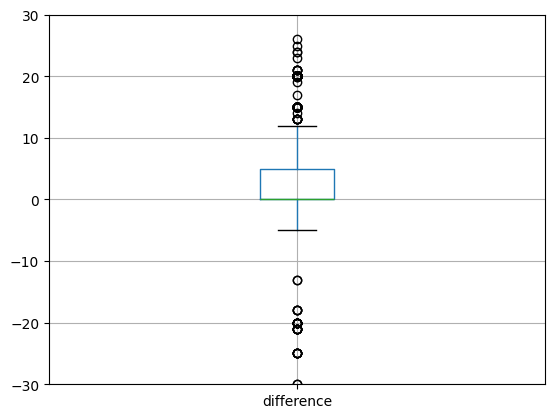

In [26]:
import matplotlib.pyplot as plt

box = merged_df.boxplot("difference");
box.set_ylim(-30, +30)
plt.show()

Looking at the data spread above, some of the difference must be due to corruption as seen in .describe.
Our quartiles (0.00, 0.01, 4.99) show that most of our data fit an expected pattern - free, 0.01, and 4.99 all seem like
reasonable prices to assume as postage. However, if we look at the minimum and maximum values, -165.00 and 3984.99, this can only occur due to
corrupted data.


###What to do with these orders?

In [27]:
# calculate the quartiles
Q1 = merged_df["difference"].quantile(0.25)
Q3 = merged_df["difference"].quantile(0.75)

Q1, Q3

(0.0, 4.990000000000009)

In [28]:
# calculate the interquartile range
IQR = Q3-Q1
IQR

4.990000000000009

In [29]:
# lower boundary
Q1 - 1.5*IQR

#upper boundary
Q3 + 1.5*IQR


12.475000000000023

In [30]:
# filter the DataFrame to include only "non-outliers"
merged_no_outliers_df = merged_df.loc[
    (merged_df["difference"] >= (Q1 - 1.5*IQR))
    &
    (merged_df["difference"] <= (Q3 + 1.5*IQR))
    ,
    :]

Let's look at the distribution again to see the effect of removing the outliers.

<Axes: >

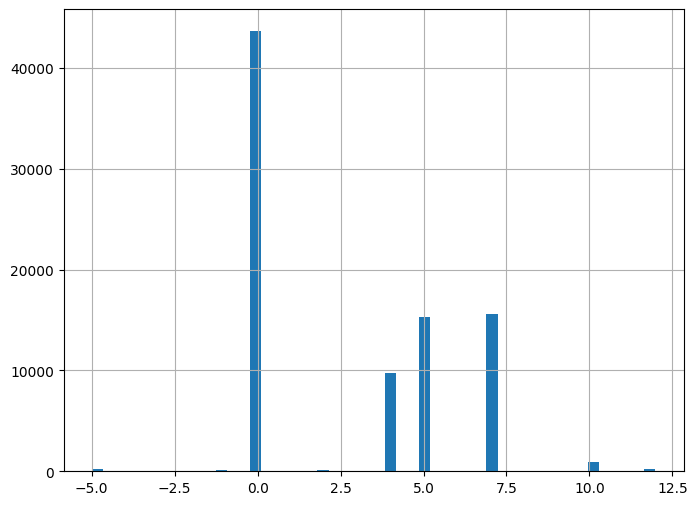

In [31]:
merged_no_outliers_df.difference.hist(bins= 50, figsize=(8,6))

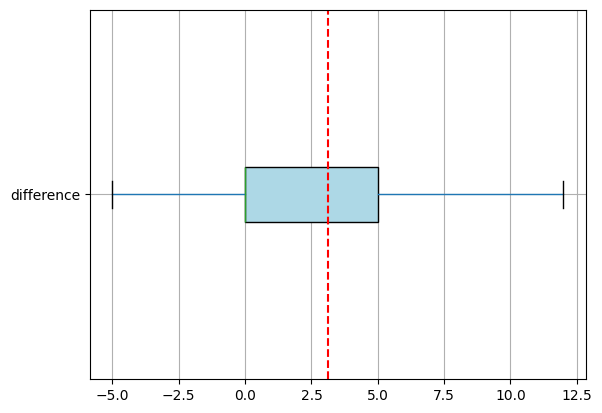

In [32]:
import matplotlib.pyplot as plt
import numpy as np

merged_no_outliers_df.boxplot("difference",vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
mean = np.mean(merged_df["difference"])
# Add the mean line
plt.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean}')

plt.show()

This looks much more like what we would expect: a small difference, but nothing extreme.

Now we need to remove these orders with extreme differences from our DataFrames.

In [33]:
normal_diff_list = merged_no_outliers_df["order_id"]

In [34]:
orders_qu = orders_qu.loc[orders_qu["order_id"].isin(normal_diff_list), :]
orderlines_qu = orderlines_qu.loc[orderlines_qu["id_order"].isin(normal_diff_list), :]

In [35]:
orders_qu.shape, orderlines_qu.shape

((85885, 4), (109550, 8))

In [36]:
orderlines_qu['sku'].nunique(), products_qu['sku'].nunique()

(6733, 10180)

In [37]:
#Downloading these quality-controlled dataframes.

from google.colab import files

orders_qu.to_csv("orders_qu.csv", index=False)
files.download("orders_qu.csv")

orderlines_qu.to_csv("orderlines_qu.csv", index=False)
files.download("orderlines_qu.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>